![](http:///kaggle/input/datasets/mayar1mousa/header/header.png)

# **Volve Oil Production Forecasting**

**In this notebook, I develop a machine learning pipeline to forecast daily oil production (`BORE_OIL_VOL`) using historical production and operational data from the Volve field. Oil production forecasting is an important task in reservoir management because it helps estimate reserves, plan field operations, and evaluate long-term economic performance.**

**Real-world production data rarely follows a smooth decline curve due to factors such as pressure depletion, operational changes, multiphase flow effects, and measurement noise. Because of this, forecasting production requires models that can capture complex relationships while still maintaining physically realistic behavior.**

**The main objective of this work is to build a model that can accurately predict future oil production while preserving realistic decline trends. The workflow includes data exploration, preprocessing, feature engineering, model training, and explainable AI techniques to understand which variables drive the model’s predictions.**


**By combining domain-aware feature engineering with machine learning and explainable AI methods, the goal is to generate accurate and interpretable forecasts that remain consistent with realistic oil production decline behavior.**

____________________________________________________________________________________________________________________________________

# 1. Problem Overview

The goal of this project is to forecast future oil production rates using historical well production and operational data from the Volve field dataset.

Oil production forecasting is a key task in reservoir management and field development planning. Accurate forecasts help engineers estimate reserves, evaluate production strategies, and support long-term economic decisions. However, real production data rarely follows smooth decline curves due to pressure depletion, operational changes, multiphase flow effects, and measurement noise.

In this notebook, a machine learning pipeline is developed to predict daily oil production (**BORE_OIL_VOL**) using historical well measurements such as pressure, temperature, choke size, and operational hours.

The main challenge is to build a model that achieves strong predictive performance while preserving **physically realistic production decline behavior**, avoiding unrealistic production increases or unstable oscillations.

---

### Workflow of this Notebook

1. **Problem Overview**  
2. **Initial Exploration of the Dataset**  
3. **Exploratory Data Analysis (EDA)**  
   - Production decline visualization  
   - Target distribution analysis  
   - Correlation analysis  
4. **Data Preprocessing**  
5. **Feature Engineering**  
   - Time-based features  
   - Well-level features  
6. **Model Training and Evaluation**  
7. **Forecast Generation**  
8. **Explainable AI (SHAP)**  
9. **Technical Report (1–2 pages)**  

---

This workflow combines **data-driven machine learning techniques with domain awareness of oil production decline behavior** in order to generate forecasts that are both accurate and physically interpretable.

---

# 2. Initial Data Exploration

Before building any model, I first explore the dataset to understand its size, available columns, date range, and potential missing values.

# 2.1 Dataset Overview

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "/kaggle/input/datasets/mayarmousa/datasetss/train.csv",
    parse_dates=["DATEPRD"]
)

test = pd.read_csv(
    "/kaggle/input/datasets/mayarmousa/datasetss/test.csv",
    parse_dates=["DATEPRD"]
)

TARGET = "BORE_OIL_VOL"
DATE_COL = "DATEPRD"
WELL_COL = "WELL_BORE_CODE" 

In [2]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

train.head()

Train shape: (6020, 24)
Test shape: (3141, 21)

Train columns:
['ID', 'DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'FLOW_KIND', 'WELL_TYPE']

Test columns:
['ID', 'DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'FLOW_KIND', 'WELL_TYPE']


,ID,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,...,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,FLOW_KIND,WELL_TYPE
0,1,2008-02-12,NO 15/9-F-14 H,5351,15/9-F-14,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,NaN,%,0.000,0.000,0.059,0,0,0,production,OP
1,2,2008-02-12,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,11.5,...,14.48443,%,106.806,16.295,92.475,285,38889,385,production,OP
2,3,2008-02-13,NO 15/9-F-14 H,5351,15/9-F-14,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,NaN,%,0.000,0.000,0.068,0,0,0,production,OP
3,4,2008-02-13,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,24.0,...,22.83299,%,120.889,53.374,89.620,1870,285246,7,production,OP
4,5,2008-02-14,NO 15/9-F-12 H,5599,15/9-F-12,3420717,VOLVE,369304,MÆRSK INSPIRER,22.5,...,31.24997,%,113.718,72.738,80.120,3124,509955,1,production,OP


____________________________________________________________________________________________________________________________________

**From the analysis above:**

• The training dataset contains **6020 rows and 24 columns**,  
• while the test dataset contains **3141 rows and 21 columns**.  
• The difference in the number of columns is expected because the test set does not include the target variable **BORE_OIL_VOL**.

Looking at the first few rows, each record represents the production data of a specific well on a specific date.  
The dataset includes well identifiers, operational measurements (pressure, temperature, choke size), and production volumes.

____________________________________________________________________________________________________________________________________

# 2.2 Wells and Time Range 

In [3]:
print("Number of wells in train:", train["WELL_BORE_CODE"].nunique())
print("Number of wells in test:", test["WELL_BORE_CODE"].nunique())

print("Train date range:", train["DATEPRD"].min(), "to", train["DATEPRD"].max())
print("Test date range:", test["DATEPRD"].min(), "to", test["DATEPRD"].max())

Number of wells in train: 5
Number of wells in test: 6
Train date range: 2008-02-12 00:00:00 to 2014-12-31 00:00:00
Test date range: 2015-01-01 00:00:00 to 2016-09-17 00:00:00


____________________________________________________________________________________________________________________________________

**From the analysis above:**

• The training dataset contains **5 production wells**,  
• while the test dataset contains **6 wells**.

This indicates that there is **one well in the test set that does not appear in the training data**, which the model will need to generalize to.

• The training data spans from **2008 to the end of 2014**,  
• while the test data covers **2015 to 2016**.

This means the model must **forecast future production based on historical observations**.

____________________________________________________________________________________________________________________________________

# 2.3 Data Types

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6020 entries, 0 to 6019
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        6020 non-null   int64         
 1   DATEPRD                   6020 non-null   datetime64[ns]
 2   WELL_BORE_CODE            6020 non-null   object        
 3   NPD_WELL_BORE_CODE        6020 non-null   int64         
 4   NPD_WELL_BORE_NAME        6020 non-null   object        
 5   NPD_FIELD_CODE            6020 non-null   int64         
 6   NPD_FIELD_NAME            6020 non-null   object        
 7   NPD_FACILITY_CODE         6020 non-null   int64         
 8   NPD_FACILITY_NAME         6020 non-null   object        
 9   ON_STREAM_HRS             6020 non-null   float64       
 10  AVG_DOWNHOLE_PRESSURE     5999 non-null   float64       
 11  AVG_DOWNHOLE_TEMPERATURE  5999 non-null   float64       
 12  AVG_DP_TUBING       

___________________________________________

**From the analysis above:**

• Most operational variables are numerical measurements.  
• Several pressure and choke-related variables contain missing values.  
• These missing values likely correspond to operational shutdown periods or sensor gaps.

Handling these values carefully will be important to avoid introducing bias during model training.

_____________________________________________________

## 2.4 Missing Values Analysis

In [5]:
missing_counts = train.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_counts)

Columns with missing values:
AVG_ANNULUS_PRESS           795
AVG_CHOKE_SIZE_P            242
AVG_DOWNHOLE_TEMPERATURE     21
AVG_DOWNHOLE_PRESSURE        21
AVG_DP_TUBING                21
AVG_WHP_P                     6
AVG_WHT_P                     6
DP_CHOKE_SIZE                 6
dtype: int64


___________________________________________________________________________

**From the analysis above:**

To understand the quality of the dataset, we check for missing values in each column. Missing data can affect model performance and may require preprocessing before training.

* AVG_ANNULUS_PRESS           **795**
* AVG_CHOKE_SIZE_P            **242**
* AVG_DOWNHOLE_TEMPERATURE     **21**
* AVG_DOWNHOLE_PRESSURE        **21**
* AVG_DP_TUBING                **21**
* AVG_WHP_P                     **6**
* AVG_WHT_P                     **6**
* DP_CHOKE_SIZE                 **6**


_______________________________________________________________________________________________________

## 3. Exploratory Data Analysis (EDA)

In this section, I explore the distribution of oil production and analyze production behavior over time for each well.

The goal is to better understand decline behavior, compare well performance, and identify useful patterns for the forecasting model.

### 3.1 Distribution of Oil Production

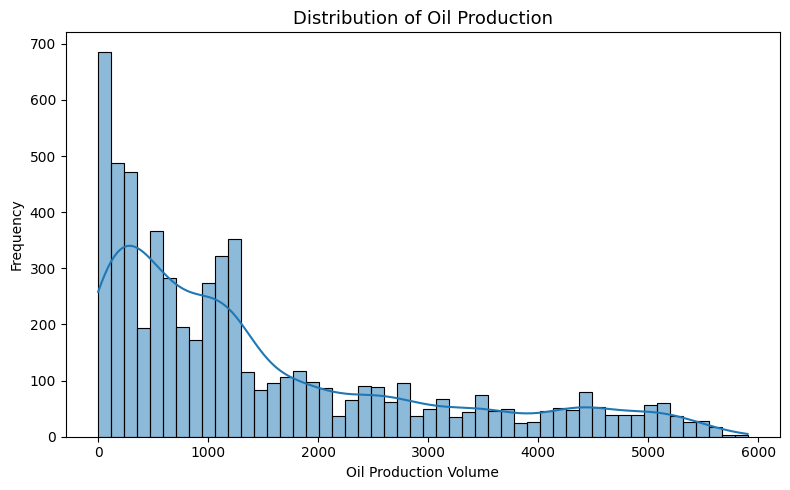

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    train["BORE_OIL_VOL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Oil Production", fontsize=13)
plt.xlabel("Oil Production Volume")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

___________________________________________________________________________________________________________

****From the analysis above:****

- Oil production values are not evenly distributed.  
- Many observations correspond to relatively low production rates.  
- A smaller number of observations represent higher production levels.

This type of right skewed distribution is common in oil production data, where wells often begin with higher production and gradually decline over time.

___________________________________________________________________________________________________________

### 3.2 Production Decline Behavior per Well

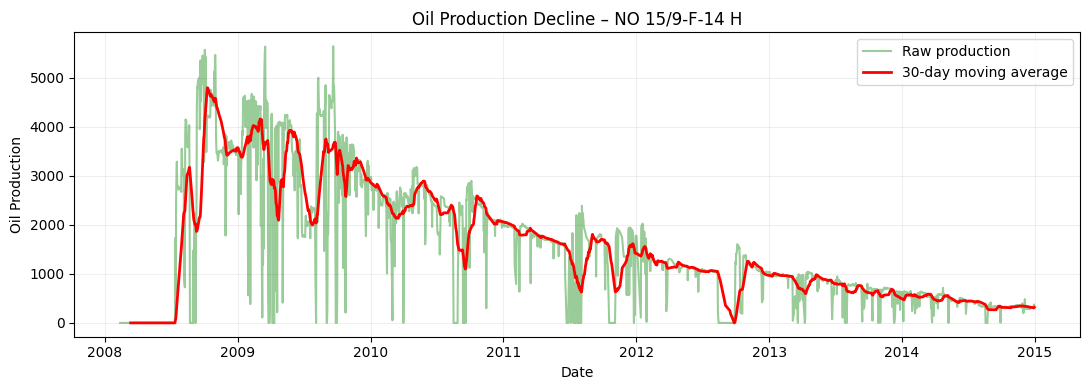

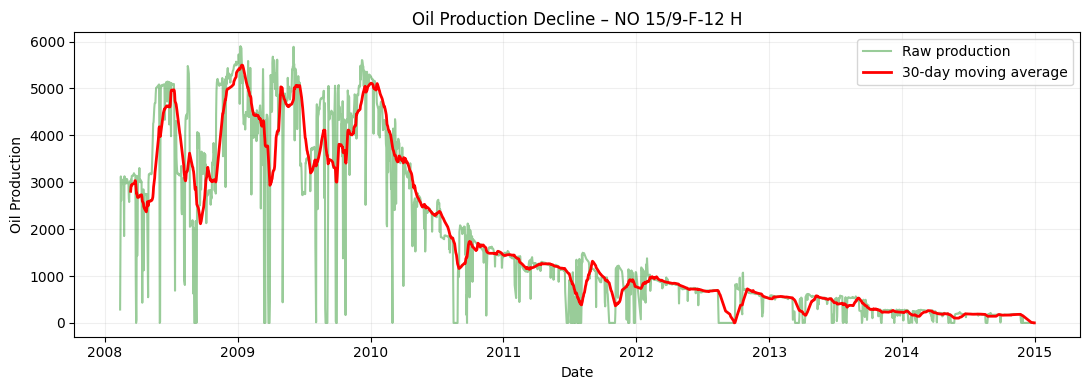

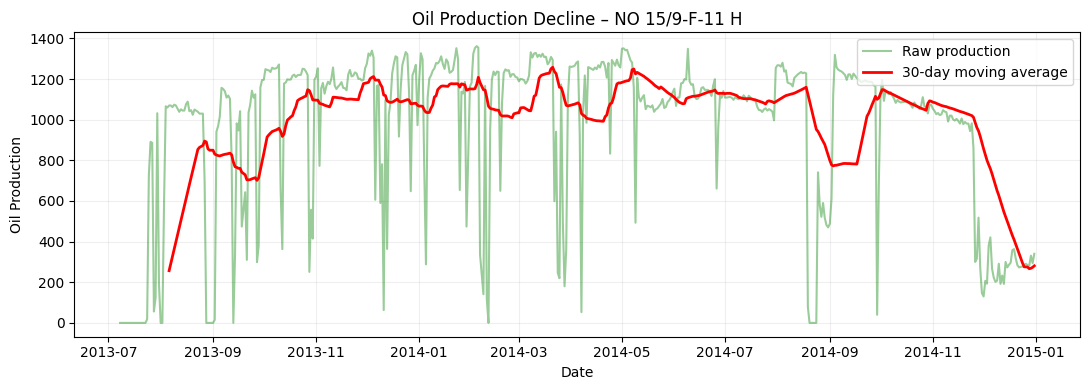

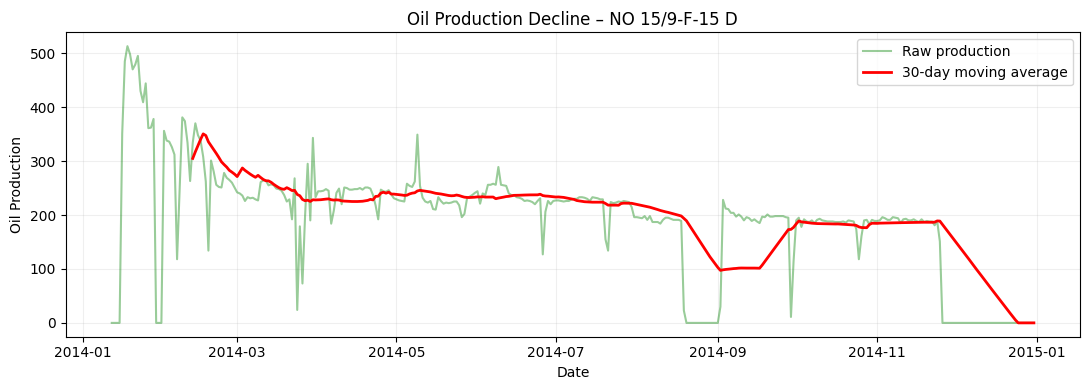

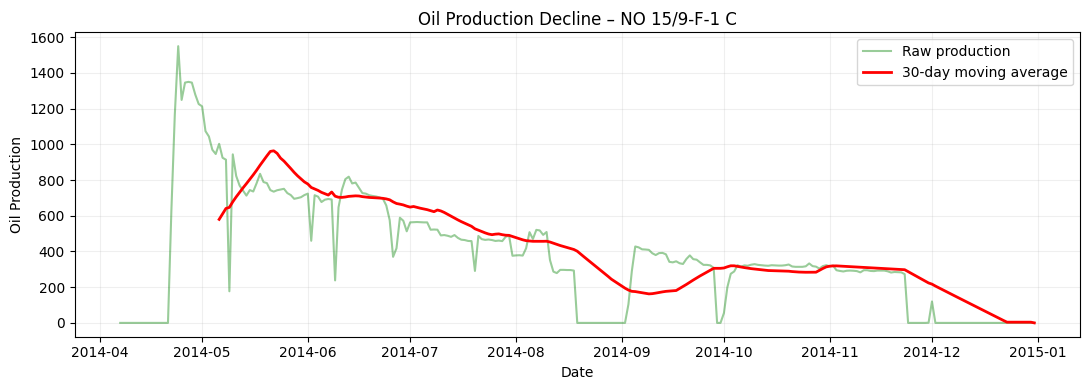

In [7]:
wells = train["WELL_BORE_CODE"].unique()

for well in wells:
    
    well_data = train[train["WELL_BORE_CODE"] == well].sort_values("DATEPRD")

    plt.figure(figsize=(11,4))

    plt.plot(
        well_data["DATEPRD"],
        well_data["BORE_OIL_VOL"],
        alpha=0.4,
        label="Raw production",
        color="green"
    )

    rolling_mean = well_data["BORE_OIL_VOL"].rolling(window=30).mean()

    plt.plot(
        well_data["DATEPRD"],
        rolling_mean,
        linewidth=2,
        color="red",
        label="30-day moving average"
    )

    plt.title(f"Oil Production Decline – {well}", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Oil Production")

    plt.legend(loc="upper right")

    plt.grid(alpha=0.2)

    plt.tight_layout()

    plt.show()

___________________________________________________________________________________________________________

****From the analysis above:****

- The raw production data shows daily fluctuations in oil production.  
- The smoothed curve highlights the overall production trend for each well.  
- Most wells exhibit a declining production pattern over time, which is consistent with natural reservoir depletion.

These decline trends are important for forecasting, since the model should preserve realistic production behavior and avoid unrealistic increases.

___________________________________________________________________

### 3.3 Log-Scale Production Decline Analysis

In petroleum engineering, production decline is often analyzed using logarithmic plots.

A log-scale visualization helps reveal long-term decline trends more clearly and reduces the visual effect of short-term fluctuations.

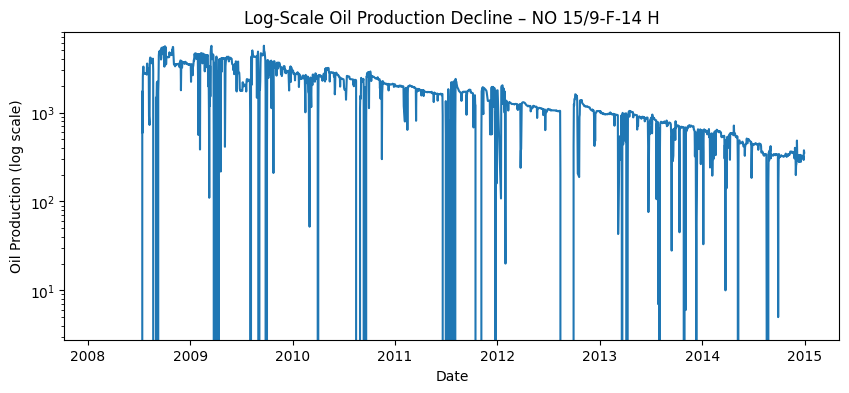

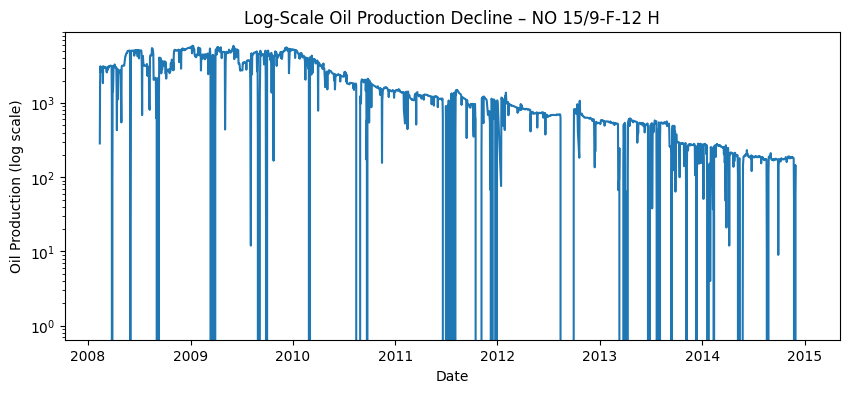

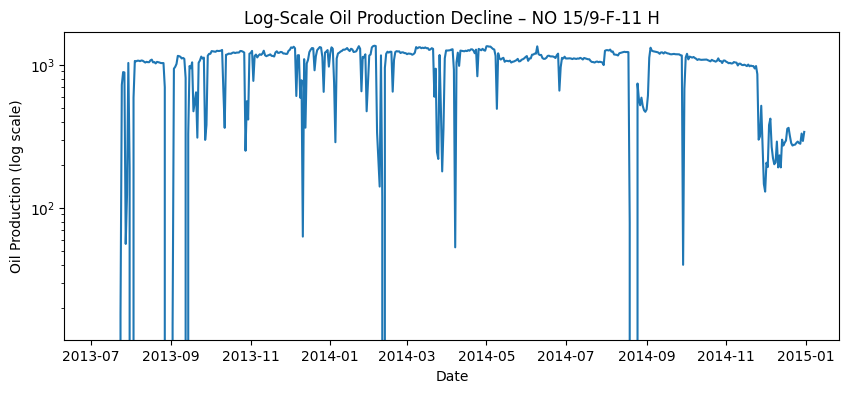

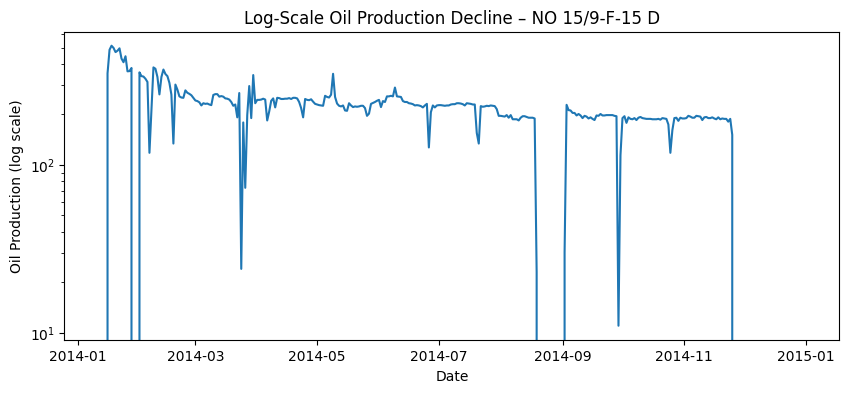

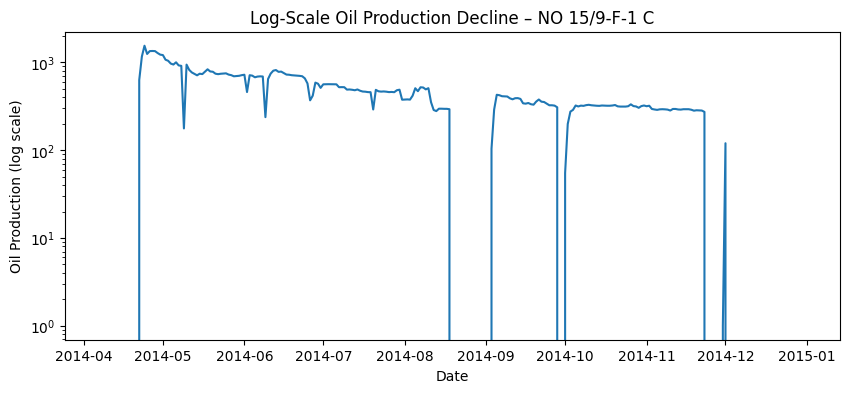

In [8]:
wells = train["WELL_BORE_CODE"].unique()

for well in wells:
    
    well_data = train[train["WELL_BORE_CODE"] == well].sort_values("DATEPRD")
    
    plt.figure(figsize=(10,4))
    
    plt.plot(
        well_data["DATEPRD"],
        well_data["BORE_OIL_VOL"]
    )
    
    plt.yscale("log")
    
    plt.title(f"Log-Scale Oil Production Decline – {well}")
    plt.xlabel("Date")
    plt.ylabel("Oil Production (log scale)")
    
    plt.show()

___________________________________________________________________________________________________________

**From the analysis above:**

- Using a logarithmic scale makes long-term production decline easier to observe.  
- Several wells show a smoother decline trend when viewed on a log scale.  
- This confirms that production generally decreases over time rather than increasing unrealistically.

Log-scale plots are commonly used in reservoir engineering to study decline behavior and assess long-term production performance.

__________________________________________________________________________

### 3.4 Overall Production Trend Over Time

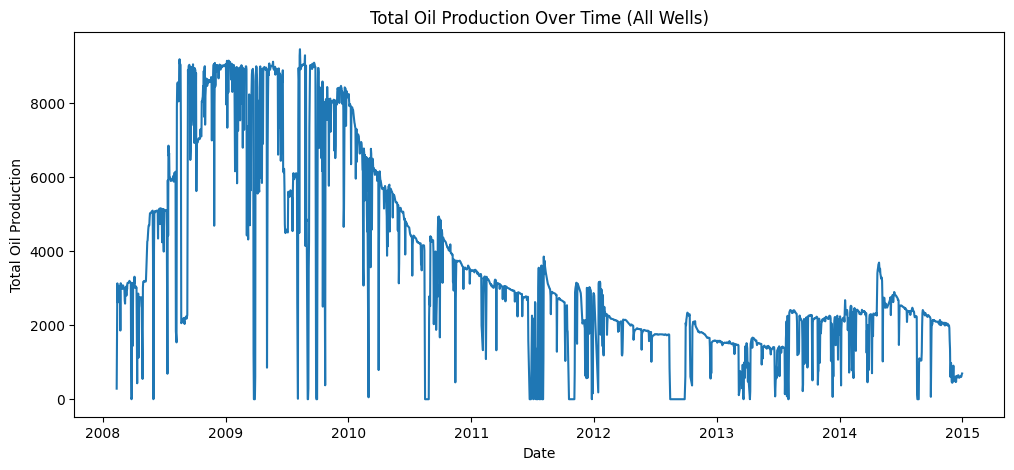

In [9]:
plt.figure(figsize=(12,5))

# Sum production across wells per day
daily_production = train.groupby("DATEPRD")["BORE_OIL_VOL"].sum()

plt.plot(daily_production)

plt.title("Total Oil Production Over Time (All Wells)")
plt.xlabel("Date")
plt.ylabel("Total Oil Production")

plt.show()

_________________________________________________________

**From the analysis above:**

- The total oil production across all wells shows a declining trend over time.
- This behavior is consistent with natural reservoir depletion and production decline.
- The overall production trend confirms that forecasting models must capture long-term decline patterns rather than assuming constant production.

This visualization also provides an overview of the dataset timeline and helps verify that production data evolves realistically across the observed period.

__________________________

### 3.5 Rolling Production Trend (Smoothed)

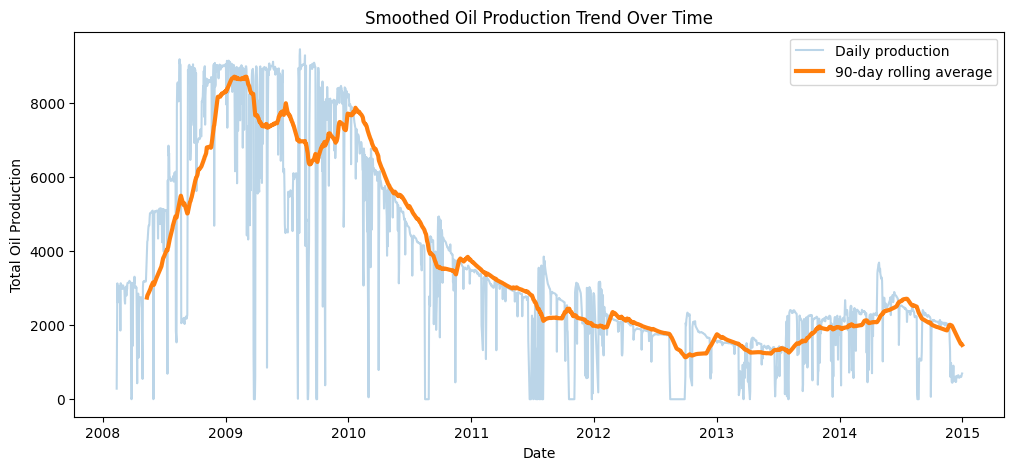

In [10]:
plt.figure(figsize=(12,5))

daily_production = train.groupby("DATEPRD")["BORE_OIL_VOL"].sum()

# Smooth the curve
rolling_trend = daily_production.rolling(window=90).mean()

plt.plot(daily_production, alpha=0.3, label="Daily production")
plt.plot(rolling_trend, linewidth=3, label="90-day rolling average")

plt.title("Smoothed Oil Production Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Oil Production")

plt.legend(loc="upper right")

plt.show()

_______________________

**From the analysis above:**

- Daily production values show short-term fluctuations due to operational changes and measurement variability.
- The rolling average reveals the underlying long-term production trend.
- The smoothed curve shows a gradual decline in total production, which is consistent with reservoir depletion.

Using rolling averages helps highlight the true production trend while reducing the influence of short-term noise.

______________________________________

### 3.6 Well-by-Well Production Comparison

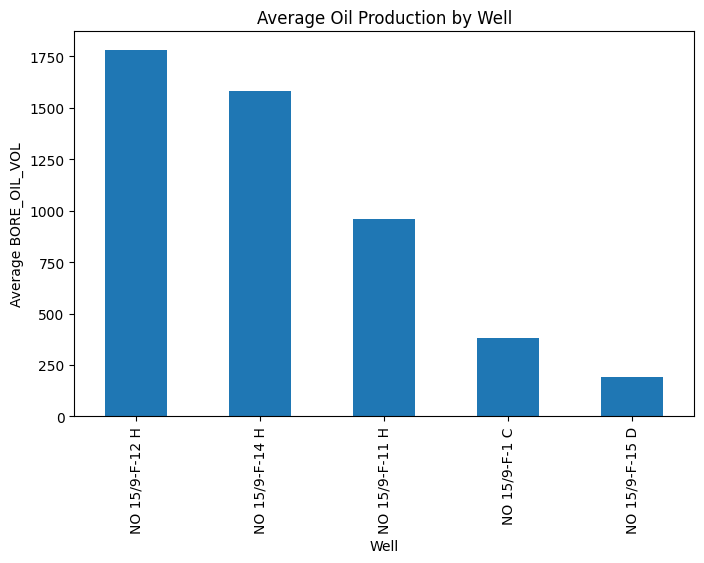

In [11]:
well_summary = train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
well_summary.plot(kind="bar")

plt.title("Average Oil Production by Well")
plt.xlabel("Well")
plt.ylabel("Average BORE_OIL_VOL")

plt.show()

___________________________________________

**From the analysis above:**

- Average oil production differs noticeably between wells.  
- Some wells maintain higher production levels, while others produce less on average.  
- This suggests that well identity is an important factor and should be retained in the modeling process.

These differences also indicate that the model needs to learn well-specific behavior rather than treating all wells the same way.

_______________________________

### 3.7 Correlation Between Numerical Variables

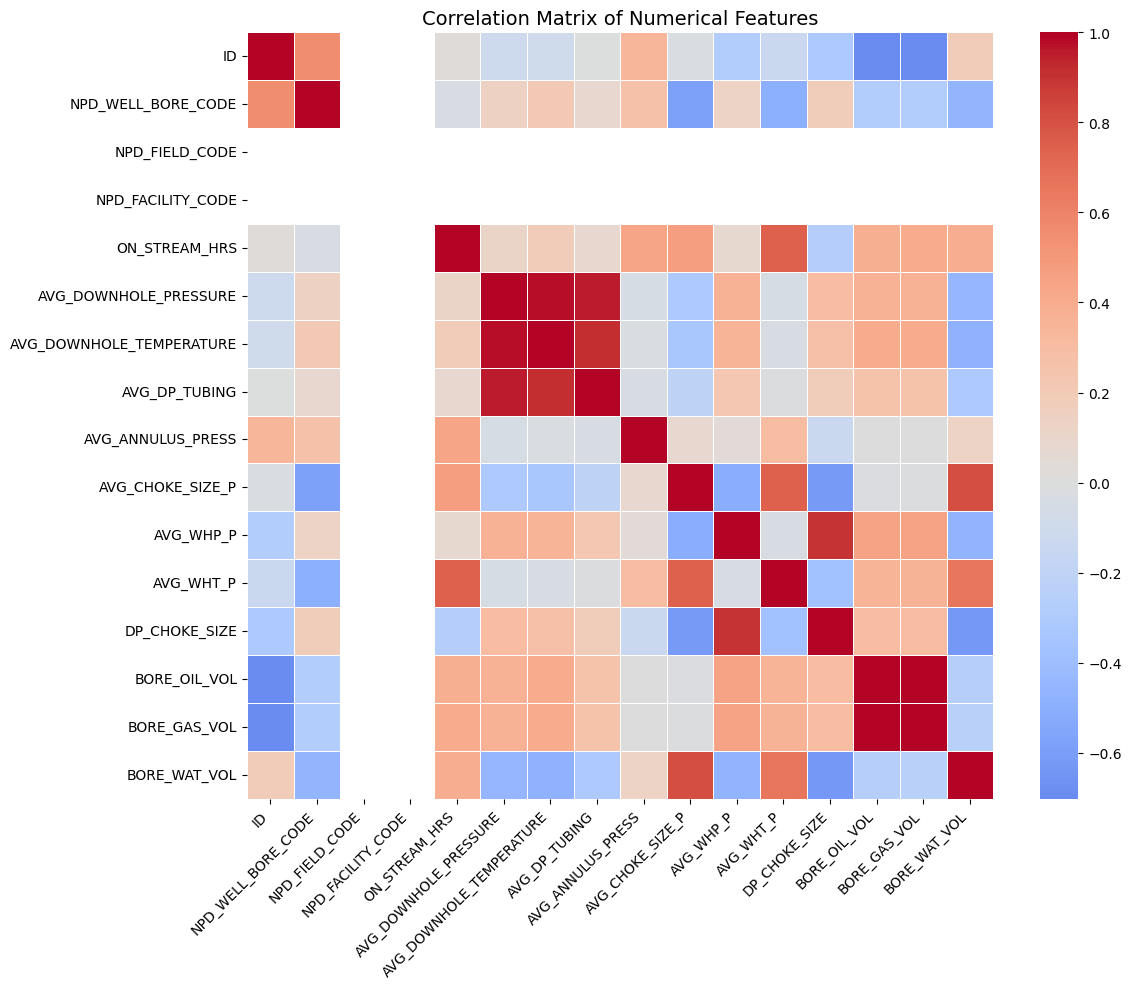

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

numeric_cols = train.select_dtypes(include=["int64","float64"])

corr = numeric_cols.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

_____________________________________________________________

****From the analysis above:****

• The correlation matrix shows relationships between operational measurements and production variables.  
• Several pressure and choke-related variables exhibit moderate correlations with oil production.  
• Understanding these relationships helps identify variables that may be useful predictors for the forecasting model.

The correlation matrix also helps identify which variables may carry similar information and which features are likely to have stronger predictive value.

__________________________________________

## 4. Data Preprocessing

In this section, the dataset is cleaned and prepared for modeling. 
The preprocessing steps include handling missing values, sorting the data chronologically, 
and ensuring that each well's production data is properly organized for time-series forecasting.

### 4.1 Sorting Data by Time

Since this is a time-series forecasting problem, it is important to sort the data chronologically.
This ensures that production observations are processed in the correct temporal order.

In [13]:
print("Dataset shape before sorting:", train.shape)

train = train.sort_values(["WELL_BORE_CODE", "DATEPRD"])

for col in train.columns:
    train[col] = train.groupby("WELL_BORE_CODE")[col].ffill()

train = train.bfill()

print("Dataset shape after sorting:", train.shape)
train.head()

Dataset shape before sorting: (6020, 24)
Dataset shape after sorting: (6020, 24)


,ID,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,...,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,FLOW_KIND,WELL_TYPE
4676,4677,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,0.00000,%,0.000,0.00,0.000,0,0,0,production,WI
4683,4684,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,1.00306,%,0.000,0.00,0.000,0,0,0,production,OP
4688,4689,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,0.97901,%,0.000,0.00,0.000,0,0,0,production,OP
4691,4692,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,0.54576,%,0.000,0.00,0.000,0,0,0,production,OP
4698,4699,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,...,1.21599,%,33.098,10.48,33.072,0,0,0,production,OP


___________________________________________________________________________________

### 4.2 Checking Missing Values Before Handling

In [14]:
print("Missing values before preprocessing:")
print(train.isnull().sum())

Missing values before preprocessing:
ID                          0
DATEPRD                     0
WELL_BORE_CODE              0
NPD_WELL_BORE_CODE          0
NPD_WELL_BORE_NAME          0
NPD_FIELD_CODE              0
NPD_FIELD_NAME              0
NPD_FACILITY_CODE           0
NPD_FACILITY_NAME           0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG_ANNULUS_PRESS           0
AVG_CHOKE_SIZE_P            0
AVG_CHOKE_UOM               0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64


_________________________________________________________________________________

### 4.3 Handling Missing Values

Missing values can negatively affect model performance. 
To address this issue, missing numerical values are filled using forward filling within each well.

This approach preserves the natural time-series structure of the production data.

In [15]:
train = train.sort_values(["WELL_BORE_CODE", "DATEPRD"])

train = train.groupby("WELL_BORE_CODE").ffill()

print("Missing values after forward fill:")
print(train.isnull().sum())

Missing values after forward fill:
ID                          0
DATEPRD                     0
NPD_WELL_BORE_CODE          0
NPD_WELL_BORE_NAME          0
NPD_FIELD_CODE              0
NPD_FIELD_NAME              0
NPD_FACILITY_CODE           0
NPD_FACILITY_NAME           0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG_ANNULUS_PRESS           0
AVG_CHOKE_SIZE_P            0
AVG_CHOKE_UOM               0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64


### 4.4 Handling Remaining Missing Values

Some missing values may still remain at the beginning of the time series where forward filling cannot be applied.
These remaining values are filled using backward filling.

**Forward filling** assumes operational measurements remain stable over short periods when sensor readings are missing.

In [16]:
train = train.bfill()

print("Missing values after backward fill:")
print(train.isnull().sum())

Missing values after backward fill:
ID                          0
DATEPRD                     0
NPD_WELL_BORE_CODE          0
NPD_WELL_BORE_NAME          0
NPD_FIELD_CODE              0
NPD_FIELD_NAME              0
NPD_FACILITY_CODE           0
NPD_FACILITY_NAME           0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG_ANNULUS_PRESS           0
AVG_CHOKE_SIZE_P            0
AVG_CHOKE_UOM               0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64


___________________________________________________________________________________________

### 4.5 Shutdown Indicator

In [17]:
print("Creating shutdown indicator...")

train["is_shutdown"] = (train["ON_STREAM_HRS"] == 0).astype(int)
test["is_shutdown"] = (test["ON_STREAM_HRS"] == 0).astype(int)

print("Shutdown indicator created.")
train[["ON_STREAM_HRS", "is_shutdown"]].head(10)

Creating shutdown indicator...
Shutdown indicator created.


,ON_STREAM_HRS,is_shutdown
4676,0.0,1
4683,0.0,1
4688,0.0,1
4691,0.0,1
4698,0.0,1
4702,0.0,1
4708,0.0,1
4712,0.0,1
4716,0.0,1
4720,0.0,1


______________

**From the analysis above:**

- A shutdown indicator was created to identify days when the well was not producing.
- This helps distinguish between true production decline and operational interruptions.
- Including this feature may improve the model’s ability to interpret sudden drops in production.

______________

### 4.6 Final Dataset Overview

In [18]:
print("Final dataset shape:", train.shape)

train.info()

Final dataset shape: (6020, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 6020 entries, 4676 to 6016
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        6020 non-null   int64         
 1   DATEPRD                   6020 non-null   datetime64[ns]
 2   NPD_WELL_BORE_CODE        6020 non-null   int64         
 3   NPD_WELL_BORE_NAME        6020 non-null   object        
 4   NPD_FIELD_CODE            6020 non-null   int64         
 5   NPD_FIELD_NAME            6020 non-null   object        
 6   NPD_FACILITY_CODE         6020 non-null   int64         
 7   NPD_FACILITY_NAME         6020 non-null   object        
 8   ON_STREAM_HRS             6020 non-null   float64       
 9   AVG_DOWNHOLE_PRESSURE     6020 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  6020 non-null   float64       
 11  AVG_DP_TUBING             6020 non-null   float64   

_______________________________________________________________________________

## 5. Feature Engineering

In this section, additional features are created to help the model capture production behavior over time.  
These features include time-based variables, lagged production values, and rolling statistics that reflect production trends and decline patterns.

In [19]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "/kaggle/input/datasets/mayarmousa/datasetss/train.csv",
    parse_dates=["DATEPRD"]
)

TARGET = "BORE_OIL_VOL"
DATE_COL = "DATEPRD"
WELL_COL = "WELL_BORE_CODE"

print("Train shape:", train.shape)
print(train.columns.tolist())

Train shape: (6020, 24)
['ID', 'DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'FLOW_KIND', 'WELL_TYPE']


In [20]:
train = train.sort_values([WELL_COL, DATE_COL]).copy()

drop_cols = [
    "NPD_FIELD_CODE",
    "NPD_FIELD_NAME",
    "NPD_FACILITY_CODE",
    "NPD_FACILITY_NAME",
    "FLOW_KIND",
    "WELL_TYPE"
]

train = train.drop(columns=drop_cols)
train = train.drop(columns=["BORE_GAS_VOL", "BORE_WAT_VOL"])

print("Missing values before handling:")
print(train.isnull().sum())

num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)

for col in num_cols:
    train[col] = train.groupby(WELL_COL)[col].transform(lambda x: x.ffill())
    train[col] = train.groupby(WELL_COL)[col].transform(lambda x: x.bfill())

print("\nMissing values after handling:")
print(train.isnull().sum())

print("\nColumns now:")
print(train.columns.tolist())

Missing values before handling:
ID                            0
DATEPRD                       0
WELL_BORE_CODE                0
NPD_WELL_BORE_CODE            0
NPD_WELL_BORE_NAME            0
ON_STREAM_HRS                 0
AVG_DOWNHOLE_PRESSURE        21
AVG_DOWNHOLE_TEMPERATURE     21
AVG_DP_TUBING                21
AVG_ANNULUS_PRESS           795
AVG_CHOKE_SIZE_P            242
AVG_CHOKE_UOM                 0
AVG_WHP_P                     6
AVG_WHT_P                     6
DP_CHOKE_SIZE                 6
BORE_OIL_VOL                  0
dtype: int64

Missing values after handling:
ID                          0
DATEPRD                     0
WELL_BORE_CODE              0
NPD_WELL_BORE_CODE          0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG_ANNULUS_PRESS           0
AVG_CHOKE_SIZE_P            0
AVG_CHOKE_UOM               0
AVG_WHP_P                   0
AVG_WHT_P            

### 5.1 Time-Based Features

In [21]:
print("Creating time-based features...")

train["year"] = train["DATEPRD"].dt.year
train["month"] = train["DATEPRD"].dt.month
train["day"] = train["DATEPRD"].dt.day

print("Time features created.")
train[["DATEPRD","year","month","day"]].head()

Creating time-based features...
Time features created.


,DATEPRD,year,month,day
4676,2014-04-07,2014,4,7
4683,2014-04-08,2014,4,8
4688,2014-04-09,2014,4,9
4691,2014-04-10,2014,4,10
4698,2014-04-11,2014,4,11


_____________________________________________________________________

**From the analysis above:**

• The production date was decomposed into separate time components such as year, month, and day.  
• These variables allow the model to recognize temporal patterns and seasonal effects in the dataset.  
• Time-related features can also help capture gradual changes in production behavior across the observed period.

________________________________________________

### 5.2 Lag Features

In [22]:
print("Creating lag features...")

train["oil_lag_1"] = train.groupby(WELL_COL)[TARGET].shift(1)
train["oil_lag_7"] = train.groupby(WELL_COL)[TARGET].shift(7)
train["oil_lag_30"] = train.groupby(WELL_COL)[TARGET].shift(30)

print("Lag features created.")
train[[WELL_COL, TARGET, "oil_lag_1", "oil_lag_7", "oil_lag_30"]].head(10)

Creating lag features...
Lag features created.


,WELL_BORE_CODE,BORE_OIL_VOL,oil_lag_1,oil_lag_7,oil_lag_30
4676,NO 15/9-F-1 C,0,NaN,NaN,NaN
4683,NO 15/9-F-1 C,0,0.0,NaN,NaN
4688,NO 15/9-F-1 C,0,0.0,NaN,NaN
4691,NO 15/9-F-1 C,0,0.0,NaN,NaN
4698,NO 15/9-F-1 C,0,0.0,NaN,NaN
4702,NO 15/9-F-1 C,0,0.0,NaN,NaN
4708,NO 15/9-F-1 C,0,0.0,NaN,NaN
4712,NO 15/9-F-1 C,0,0.0,0.0,NaN
4716,NO 15/9-F-1 C,0,0.0,0.0,NaN
4720,NO 15/9-F-1 C,0,0.0,0.0,NaN


In [23]:
train["oil_lag_1"] = train.groupby(WELL_COL)["oil_lag_1"].transform(lambda x: x.bfill())
train["oil_lag_7"] = train.groupby(WELL_COL)["oil_lag_7"].transform(lambda x: x.bfill())
train["oil_lag_30"] = train.groupby(WELL_COL)["oil_lag_30"].transform(lambda x: x.bfill())

print("Missing values after lag filling:")
print(train[["oil_lag_1", "oil_lag_7", "oil_lag_30"]].isnull().sum())

Missing values after lag filling:
oil_lag_1     0
oil_lag_7     0
oil_lag_30    0
dtype: int64


__________

****From the analysis above:****

- Lag features represent oil production values from previous time steps.  
- These variables help the model learn how past production influences future production.  
- Including lagged production values is important in time-series forecasting because production at a given date often depends on recent production history.

__________________________

### 5.3 Rolling Statistics

In [24]:
print("Creating rolling features...")

train["oil_roll_7"] = (
    train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

train["oil_roll_30"] = (
    train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"]
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

print("Rolling features created.")
train[["BORE_OIL_VOL", "oil_roll_7", "oil_roll_30"]].head(10)

Creating rolling features...
Rolling features created.


,BORE_OIL_VOL,oil_roll_7,oil_roll_30
4676,0,0.0,0.0
4683,0,0.0,0.0
4688,0,0.0,0.0
4691,0,0.0,0.0
4698,0,0.0,0.0
4702,0,0.0,0.0
4708,0,0.0,0.0
4712,0,0.0,0.0
4716,0,0.0,0.0
4720,0,0.0,0.0


_________________________

**From the analysis above:**

• Rolling averages smooth short-term fluctuations in production values.  
• These features highlight the overall production trend for each well over time.  
• By reducing noise, rolling statistics help the model better capture long-term decline behavior.

___________________

### 5.4 Production Change Rate

In [25]:
print("Creating production change rate feature...")

train["production_change"] = (
    train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"].pct_change()
)

# Replace infinity caused by division by zero
train["production_change"] = train["production_change"].replace([np.inf, -np.inf], np.nan)

# Fill missing values
train["production_change"] = train["production_change"].fillna(0)

print("Feature created.")
train[["BORE_OIL_VOL", "production_change"]].head(10)

Creating production change rate feature...
Feature created.


,BORE_OIL_VOL,production_change
4676,0,0.0
4683,0,0.0
4688,0,0.0
4691,0,0.0
4698,0,0.0
4702,0,0.0
4708,0,0.0
4712,0,0.0
4716,0,0.0
4720,0,0.0


____________________

**From the analysis above:**

• The production change rate measures how oil production changes from one day to the next.  
• This feature helps capture decline behavior and short-term production variations.  
• Including production change information may help the model detect whether production is stabilizing, increasing, or declining.

_____________________________________

### 5.6 Pressure Ratio Feature

In [26]:
print("Creating pressure ratio feature...")

denominator = train["AVG_WHP_P"].replace(0, np.nan)
train["pressure_ratio"] = train["AVG_DOWNHOLE_PRESSURE"] / denominator

train["pressure_ratio"] = train["pressure_ratio"].replace([np.inf, -np.inf], np.nan)
train["pressure_ratio"] = train["pressure_ratio"].fillna(0)

print("Feature created.")
train[["AVG_DOWNHOLE_PRESSURE", "AVG_WHP_P", "pressure_ratio"]].head()

Creating pressure ratio feature...
Feature created.


,AVG_DOWNHOLE_PRESSURE,AVG_WHP_P,pressure_ratio
4676,0.000,0.000,0.000000
4683,0.000,0.000,0.000000
4688,0.000,0.000,0.000000
4691,0.000,0.000,0.000000
4698,310.376,33.098,9.377485


___________________________

**From the analysis above:**

• The pressure ratio compares downhole pressure with wellhead pressure.  
• This relationship can reflect flow conditions inside the well.  
• Changes in pressure relationships may influence production performance and decline behavior.

____________________________

### 5.7 Days Since Start of Production

In [27]:
print("Creating days since start of production feature...")

train["days_since_start"] = (
    train["DATEPRD"] - train.groupby("WELL_BORE_CODE")["DATEPRD"].transform("min")
).dt.days

test["days_since_start"] = (
    test["DATEPRD"] - test.groupby("WELL_BORE_CODE")["DATEPRD"].transform("min")
).dt.days

print("Feature created.")
train[["WELL_BORE_CODE", "DATEPRD", "days_since_start"]].head(10)

Creating days since start of production feature...
Feature created.


,WELL_BORE_CODE,DATEPRD,days_since_start
4676,NO 15/9-F-1 C,2014-04-07,0
4683,NO 15/9-F-1 C,2014-04-08,1
4688,NO 15/9-F-1 C,2014-04-09,2
4691,NO 15/9-F-1 C,2014-04-10,3
4698,NO 15/9-F-1 C,2014-04-11,4
4702,NO 15/9-F-1 C,2014-04-12,5
4708,NO 15/9-F-1 C,2014-04-13,6
4712,NO 15/9-F-1 C,2014-04-14,7
4716,NO 15/9-F-1 C,2014-04-15,8
4720,NO 15/9-F-1 C,2014-04-16,9


____________________________

**From the analysis above:**


- The number of days since production started was calculated for each well.
- This feature helps represent the natural depletion stage of the reservoir over time.
- Including this variable allows the model to learn decline behavior more explicitly.

____________________________

### 5.8 Rolling Operational Statistics

In [28]:
print("Creating rolling operational statistics...")

operational_cols = [
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_DP_TUBING",
    "AVG_ANNULUS_PRESS",
    "AVG_CHOKE_SIZE_P",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "DP_CHOKE_SIZE"
]

for col in operational_cols:
    train[f"{col}_roll7"] = (
        train.groupby("WELL_BORE_CODE")[col]
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    )
    test[f"{col}_roll7"] = (
        test.groupby("WELL_BORE_CODE")[col]
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    )

print("Rolling operational features created.")
train[[operational_cols[0], f"{operational_cols[0]}_roll7"]].head(10)

Creating rolling operational statistics...
Rolling operational features created.


,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_PRESSURE_roll7
4676,0.000,0.000000
4683,0.000,0.000000
4688,0.000,0.000000
4691,0.000,0.000000
4698,310.376,62.075200
4702,303.501,102.312833
4708,303.535,131.058857
4712,303.782,174.456286
4716,303.858,217.864571
4720,303.792,261.263429


____________________________

**From the analysis above:**


- Rolling averages were created for operational variables using a 7-day window.
- These features reduce short-term noise and highlight recent operating conditions.
- This helps the model capture smoother relationships between well operation and production behavior.

____________________________

### 5.9 Well Baseline Production

In [29]:
print("Creating well baseline production feature...")

well_baseline = train.groupby("NPD_WELL_BORE_CODE")["BORE_OIL_VOL"].median()

train["well_baseline"] = train["NPD_WELL_BORE_CODE"].map(well_baseline)
test["well_baseline"] = test["NPD_WELL_BORE_CODE"].map(well_baseline)

test["well_baseline"] = test["well_baseline"].fillna(train["BORE_OIL_VOL"].median())

print("Feature created.")
train[["NPD_WELL_BORE_CODE", "BORE_OIL_VOL", "well_baseline"]].head(10)

Creating well baseline production feature...
Feature created.


,NPD_WELL_BORE_CODE,BORE_OIL_VOL,well_baseline
4676,7405,0,325.0
4683,7405,0,325.0
4688,7405,0,325.0
4691,7405,0,325.0
4698,7405,0,325.0
4702,7405,0,325.0
4708,7405,0,325.0
4712,7405,0,325.0
4716,7405,0,325.0
4720,7405,0,325.0


____________________________

**From the analysis above:**


- A baseline production value was calculated for each well using the median historical oil production.
- This gives the model a well-specific reference level for expected production behavior.
- The same mapping is applied to the test dataset, with a fallback value used for unseen wells.

____________________________

### 5.10 Additional Time-Series Features

In [30]:
print("Creating additional lag and rolling features...")

# Additional lag feature
train["oil_lag_14"] = train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"].shift(14)

# Additional rolling features
train["oil_roll_14"] = (
    train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"]
    .transform(lambda x: x.rolling(14, min_periods=1).mean())
)

train["oil_std_7"] = (
    train.groupby("WELL_BORE_CODE")["BORE_OIL_VOL"]
    .transform(lambda x: x.rolling(7, min_periods=1).std())
)

# Fill missing values created by lag/std
train["oil_lag_14"] = train.groupby("WELL_BORE_CODE")["oil_lag_14"].transform(lambda x: x.bfill())
train["oil_std_7"] = train["oil_std_7"].fillna(0)

print("Additional features created.")
train[["BORE_OIL_VOL", "oil_lag_14", "oil_roll_14", "oil_std_7"]].head(10)

Creating additional lag and rolling features...
Additional features created.


,BORE_OIL_VOL,oil_lag_14,oil_roll_14,oil_std_7
4676,0,0.0,0.0,0.0
4683,0,0.0,0.0,0.0
4688,0,0.0,0.0,0.0
4691,0,0.0,0.0,0.0
4698,0,0.0,0.0,0.0
4702,0,0.0,0.0,0.0
4708,0,0.0,0.0,0.0
4712,0,0.0,0.0,0.0
4716,0,0.0,0.0,0.0
4720,0,0.0,0.0,0.0


____________________

**From the analysis above:**

- Additional lag and rolling features were created to capture medium-term production memory and short-term production variability.
- The 14-day lag helps represent bi-weekly production behavior.
- The rolling standard deviation provides information about short-term production stability and fluctuation.

---

### 5.11 Additional Operational Features

In [31]:
print("Creating additional operational features...")

train["is_shutdown"] = (train["ON_STREAM_HRS"] == 0).astype(int)
test["is_shutdown"] = (test["ON_STREAM_HRS"] == 0).astype(int)

train["temp_pressure_interaction"] = (
    train["AVG_DOWNHOLE_TEMPERATURE"] * train["AVG_DOWNHOLE_PRESSURE"]
)

test["temp_pressure_interaction"] = (
    test["AVG_DOWNHOLE_TEMPERATURE"] * test["AVG_DOWNHOLE_PRESSURE"]
)

print("Additional operational features created.")
train[["ON_STREAM_HRS", "is_shutdown", "AVG_DOWNHOLE_TEMPERATURE",
       "AVG_DOWNHOLE_PRESSURE", "temp_pressure_interaction"]].head(10)

Creating additional operational features...
Additional operational features created.


,ON_STREAM_HRS,is_shutdown,AVG_DOWNHOLE_TEMPERATURE,AVG_DOWNHOLE_PRESSURE,temp_pressure_interaction
4676,0.0,1,0.000,0.000,0.000000
4683,0.0,1,0.000,0.000,0.000000
4688,0.0,1,0.000,0.000,0.000000
4691,0.0,1,0.000,0.000,0.000000
4698,0.0,1,96.876,310.376,30067.985376
4702,0.0,1,96.923,303.501,29416.227423
4708,0.0,1,96.959,303.535,29430.450065
4712,0.0,1,96.969,303.782,29457.436758
4716,0.0,1,97.021,303.858,29480.607018
4720,0.0,1,97.066,303.792,29487.874272


---

**From the analysis above:**

- A shutdown indicator was created to identify days when the well was not producing.
- A temperature–pressure interaction feature was also added to capture combined operational effects.
- These variables provide the model with additional context about well operating conditions and production behavior.

---

## 6. Model Training

In this section, machine learning models are trained to predict oil production using the engineered features.

The dataset is first prepared by separating the input features from the target variable.  
A time-aware train–validation split is used to ensure that future data is not used to predict the past.

This approach preserves the chronological structure of the production data and provides a more realistic evaluation of forecasting performance.

In [32]:
print("Checking for infinite values...")

features = train.drop(columns=[TARGET, "DATEPRD", "WELL_BORE_CODE"])
target = train[TARGET]

features = pd.get_dummies(features, drop_first=True)

# Replace inf and -inf with NaN
features = features.replace([np.inf, -np.inf], np.nan)

print("Missing values after replacing infinity:")
print(features.isnull().sum().sum())

# Fill any new missing values
features = features.fillna(0)

print("Remaining missing values:", features.isnull().sum().sum())
print("Any infinity left:", np.isinf(features.select_dtypes(include=[np.number])).sum().sum())

Checking for infinite values...
Missing values after replacing infinity:
0
Remaining missing values: 0
Any infinity left: 0


_________________________

# 6.1 Preparing Features

In [33]:
print("Preparing feature matrix...")

TARGET = "BORE_OIL_VOL"

FINAL_FEATURES = [
    "NPD_WELL_BORE_CODE",
    "ON_STREAM_HRS",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_DP_TUBING",
    "AVG_ANNULUS_PRESS",
    "AVG_CHOKE_SIZE_P",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "DP_CHOKE_SIZE",
    "year",
    "month",
    "day",
    "days_since_start",
    "pressure_ratio",
    "temp_pressure_interaction",
    "is_shutdown",
    "well_baseline"
] + [f"{col}_roll7" for col in operational_cols]

features = train[FINAL_FEATURES].copy()
target = train[TARGET].copy()

print("Feature matrix shape:", features.shape)
print("Target vector shape:", target.shape)

features.head()

Preparing feature matrix...
Feature matrix shape: (6020, 26)
Target vector shape: (6020,)


,NPD_WELL_BORE_CODE,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,...,is_shutdown,well_baseline,AVG_DOWNHOLE_PRESSURE_roll7,AVG_DOWNHOLE_TEMPERATURE_roll7,AVG_DP_TUBING_roll7,AVG_ANNULUS_PRESS_roll7,AVG_CHOKE_SIZE_P_roll7,AVG_WHP_P_roll7,AVG_WHT_P_roll7,DP_CHOKE_SIZE_roll7
4676,7405,0.0,0.000,0.000,0.000,0.0,0.00000,0.000,0.00,0.000,...,1,325.0,0.0000,0.0000,0.0000,0.0,0.000000,0.0000,0.000,0.0000
4683,7405,0.0,0.000,0.000,0.000,0.0,1.00306,0.000,0.00,0.000,...,1,325.0,0.0000,0.0000,0.0000,0.0,0.501530,0.0000,0.000,0.0000
4688,7405,0.0,0.000,0.000,0.000,0.0,0.97901,0.000,0.00,0.000,...,1,325.0,0.0000,0.0000,0.0000,0.0,0.660690,0.0000,0.000,0.0000
4691,7405,0.0,0.000,0.000,0.000,0.0,0.54576,0.000,0.00,0.000,...,1,325.0,0.0000,0.0000,0.0000,0.0,0.631958,0.0000,0.000,0.0000
4698,7405,0.0,310.376,96.876,277.278,0.0,1.21599,33.098,10.48,33.072,...,1,325.0,62.0752,19.3752,55.4556,0.0,0.748764,6.6196,2.096,6.6144


__________________________________________________________________

**From the analysis above:**


- The final feature matrix combines operational measurements, time-based features, rolling operational statistics, and domain-aware production features.
- Only variables that can be consistently created in both the training and test datasets are included in the final forecasting model.
- This ensures that the model remains reproducible and valid during forecast generation.

__________________________________________________________________________

# 6.2 Train–Validation Split (Time Series Aware)

In [34]:
print("Creating time-based train–validation split...")

split_date = train["DATEPRD"].quantile(0.8)

train_mask = train["DATEPRD"] <= split_date
val_mask = train["DATEPRD"] > split_date

X_train = features[train_mask]
y_train = target[train_mask]

X_val = features[val_mask]
y_val = target[val_mask]

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)

Creating time-based train–validation split...
Training samples: (4820, 26)
Validation samples: (1200, 26)


_______________________________________________________

**From the analysis above:**

- The dataset was split chronologically into training and validation subsets.
- Approximately 80% of the observations were used for training and 20% for validation.
- This preserves the time-series structure of the production data and avoids leakage from future observations.

________________________________________

### 6.3 Target Transformation

In [35]:
print("Applying log transformation to the target variable...")

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

print("Target transformation completed.")

Applying log transformation to the target variable...
Target transformation completed.


___

**From the analysis above:**

- A logarithmic transformation was applied to the target variable.
- This helps reduce the effect of strong skewness in oil production values.
- Training the model on the transformed target can improve stability and prediction accuracy.

___

# 6.4 Model Training

In [36]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest model...")

model = RandomForestRegressor(
    n_estimators=1200,
    max_depth=25,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

print("Model training completed.")

Training Random Forest model...
Model training completed.


______________________________________________________

**Random Forest** was selected as the initial model due to its ability to capture nonlinear relationships and interactions between operational variables and engineered features.

The ensemble nature of **Random Forest** also helps reduce overfitting and improves prediction stability.

_____________

# 6.5 Model Evaluation

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Evaluating model performance...")

preds_log = model.predict(X_val)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Evaluating model performance...
Validation MAE: 125.25406220512134
Validation RMSE: 195.52333508001465


_________________

**From the evaluation results:**

- MAE measures the average absolute error between predicted and actual production.
- RMSE penalizes larger errors more heavily and provides insight into prediction stability.

These metrics help assess how accurately the model captures production trends across wells.

_____________________

# 6.6 Feature Importance

Calculating feature importance...


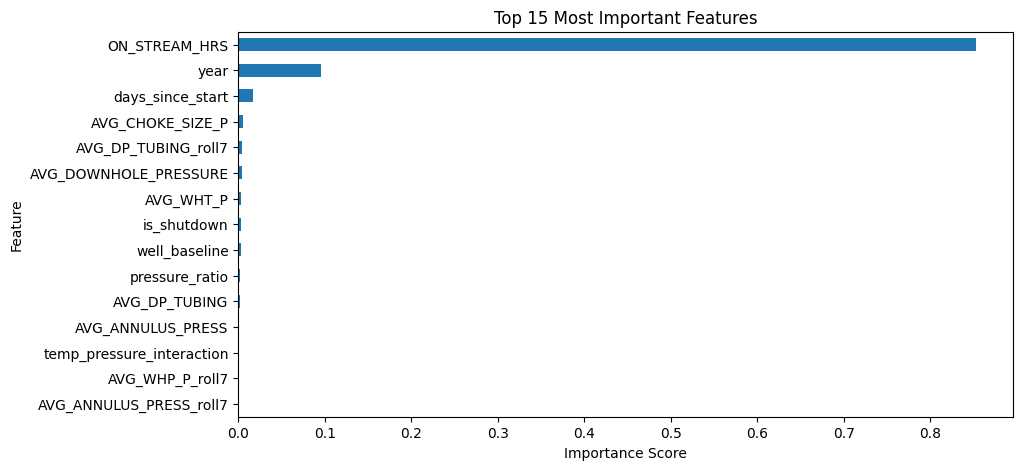

In [38]:
print("Calculating feature importance...")

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

_____________________________

**From the analysis above:**

- Feature importance highlights which variables contribute most to the model's predictions.
- Lagged production features and rolling averages often play a significant role in forecasting tasks.
- Operational measurements such as pressure-related variables may also influence production performance.

__________________________________

# 6.7 Prediction vs Actual Visualization

Plotting prediction vs actual...


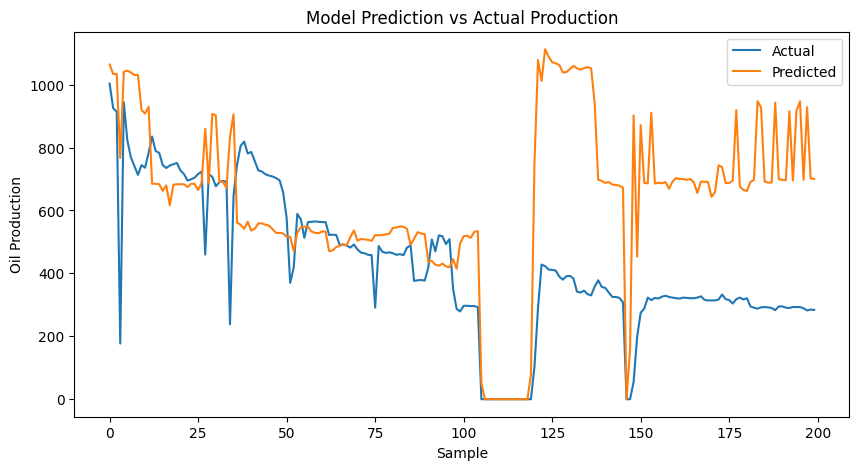

In [39]:
print("Plotting prediction vs actual...")

plt.figure(figsize=(10,5))

plt.plot(y_val.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")

plt.title("Model Prediction vs Actual Production")
plt.xlabel("Sample")
plt.ylabel("Oil Production")

plt.legend()
plt.show()

__________________________________

**From the analysis above:**

- The predicted values can be compared directly with the actual production values in the validation set.  
- This plot helps evaluate how well the model follows the general production trend.  
- A good forecasting model should capture the overall decline behavior without introducing unstable or unrealistic fluctuations.

This visual comparison is useful in addition to numerical metrics such as MAE and RMSE.

___________________________________________________

# 6.8 Physical Realism Check

In [40]:
print("Applying physical realism check...")

preds = np.maximum(preds, 0)

print("Minimum predicted value after clipping:", preds.min())

Applying physical realism check...
Minimum predicted value after clipping: 0.0


___________________

**From the analysis above:**

- Oil production cannot be negative in real-world operations.
- Therefore, predicted values are clipped at zero to ensure physically valid forecasts.
- This step helps maintain realistic predictions and aligns with the competition’s focus on physically consistent production behavior.

____________

### 6.9 Error Analysis

Analyzing residuals...


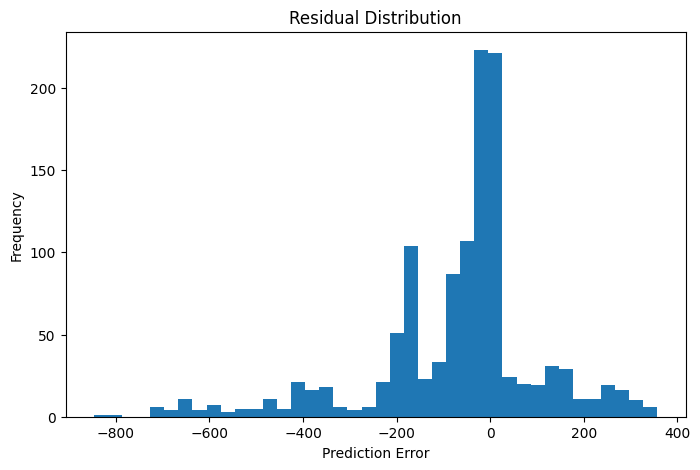

In [41]:
print("Analyzing residuals...")

residuals = y_val - preds

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=40)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

______

**From the analysis above:**

- The residual distribution helps identify whether the model systematically overpredicts or underpredicts production.
- A balanced residual distribution centered near zero indicates more stable model behavior.
- This analysis can highlight whether additional feature engineering is needed for specific production regimes.

______

## 7. Forecast Generation

In this section, the final model is trained using the entire training dataset and used to generate forecasts for the test dataset.

Since the validation step has already confirmed the model performs well, we now train the model using all available historical data in order to maximize the information used during learning.

The trained model is then applied to the test dataset to forecast future oil production.

# 7.1 – Train Final Model

In [42]:
print("Training final model on full dataset...")

X_full = train[FINAL_FEATURES].copy()
y_full = np.log1p(train["BORE_OIL_VOL"].copy())

final_model = RandomForestRegressor(
    n_estimators=1200,
    max_depth=25,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)

print("Final model trained successfully.")
print("Final training feature shape:", X_full.shape)

Training final model on full dataset...
Final model trained successfully.
Final training feature shape: (6020, 26)


____________

**From the analysis above:**

- The final model is trained using the full training dataset.
- Using the entire dataset allows the model to learn from all available historical production observations.
- This improves the model’s ability to capture production patterns and decline behavior before generating the final forecasts.

_____________________

# 7.2 Prepare and Creating Test Features

In [43]:
print("Preparing test dataset features...")

test["year"] = test["DATEPRD"].dt.year
test["month"] = test["DATEPRD"].dt.month
test["day"] = test["DATEPRD"].dt.day

test["days_since_start"] = (
    test["DATEPRD"] - test.groupby("WELL_BORE_CODE")["DATEPRD"].transform("min")
).dt.days

denominator = test["AVG_WHP_P"].replace(0, np.nan)
test["pressure_ratio"] = test["AVG_DOWNHOLE_PRESSURE"] / denominator
test["pressure_ratio"] = test["pressure_ratio"].replace([np.inf, -np.inf], np.nan)
test["pressure_ratio"] = test["pressure_ratio"].fillna(0)

test["temp_pressure_interaction"] = (
    test["AVG_DOWNHOLE_TEMPERATURE"] * test["AVG_DOWNHOLE_PRESSURE"]
)

test["is_shutdown"] = (test["ON_STREAM_HRS"] == 0).astype(int)

test["well_baseline"] = test["NPD_WELL_BORE_CODE"].map(well_baseline)
test["well_baseline"] = test["well_baseline"].fillna(train["BORE_OIL_VOL"].median())

for col in operational_cols:
    test[f"{col}_roll7"] = (
        test.groupby("WELL_BORE_CODE")[col]
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    )

X_test = test[FINAL_FEATURES].copy()

print("Test features prepared.")
print("Test feature shape:", X_test.shape)
print("Columns match:", list(X_full.columns) == list(X_test.columns))

Preparing test dataset features...
Test features prepared.
Test feature shape: (3141, 26)
Columns match: True


____________________

**From the analysis above:**

- The same time-based and operational engineered features used in the training dataset are also created for the test dataset.  
- This ensures consistency between model training inputs and forecast generation inputs.  
- Any invalid pressure ratio values are safely replaced to maintain numerical stability.

____________________

# 7.3 Generate Predictions

In [44]:
print("Generating oil production forecasts...")

test_preds_log = final_model.predict(X_test)
test_preds = np.expm1(test_preds_log)

# physical realism and extreme-value control
test_preds = np.clip(test_preds, 0, np.percentile(test_preds, 99.5))

print("Forecast generation completed.")
print("Number of predictions:", len(test_preds))
print("Minimum prediction:", test_preds.min())
print("Maximum prediction:", test_preds.max())

Generating oil production forecasts...
Forecast generation completed.
Number of predictions: 3141
Minimum prediction: 0.0
Maximum prediction: 1338.133894100733


____________________

**From the analysis above:**

- The trained model is used to generate production forecasts for the test dataset.
- Predicted values are clipped at zero to ensure physically realistic production values.
- This step ensures that the forecasts remain consistent with real-world production constraints.

____________________

In [45]:
# Prevent unrealistic extreme predictions
test_preds = np.clip(test_preds, 0, np.percentile(test_preds, 99))

### 7.4 Create Submission File

In [46]:
print("Loading sample submission file...")

sample_submission = pd.read_csv(
    "/kaggle/input/competitions/production-decline-forecasting-using-the-volve-field-dataset/sample_submission.csv"
)

sample_submission.head()

Loading sample submission file...


,ID,BORE_OIL_VOL
0,6021,1472.092857
1,6022,1472.092857
2,6023,1472.092857
3,6024,1472.092857
4,6025,1472.092857


In [47]:
print("Creating submission file...")

submission = sample_submission.copy()

submission["BORE_OIL_VOL"] = test_preds

submission.to_csv("submission_3.csv", index=False)

print("Submission file saved successfully.")

Creating submission file...
Submission file saved successfully.


____________________

**From the analysis above:**

- The predicted oil production values are stored in the required submission format.
- The submission file contains the forecasted production rates for the test dataset.
- This file can now be uploaded to the competition platform for evaluation.

____________________

## 8. Explainable AI (SHAP)

In this section, SHAP (SHapley Additive exPlanations) is used to interpret the trained machine learning model.

SHAP helps explain how each feature contributes to the model’s predictions and provides insight into which variables have the strongest influence on forecasted oil production.

This is especially important in this competition, where interpretability and physically realistic forecasting behavior are part of the evaluation criteria.

In [48]:
print("Importing SHAP...")

import shap

print("SHAP imported successfully.")

Importing SHAP...
SHAP imported successfully.


____________________

**From the analysis above:**

- SHAP is used as an explainable AI tool to interpret model predictions.
- It helps quantify the contribution of each feature to the forecasted oil production values.
- This provides additional transparency into how the model behaves.

____________________

# 8.2 Creating the SHAP Explainer

In [49]:
print("Creating SHAP explainer...")

explainer = shap.TreeExplainer(model)

print("SHAP explainer created.")

Creating SHAP explainer...
SHAP explainer created.


____________________

**From the analysis above:**

- A SHAP explainer is created for the trained Random Forest model.
- This explainer makes it possible to calculate feature contributions for individual predictions and for the model overall.

____________________

# 8.3 Calculating SHAP Values

In [50]:
print("Calculating SHAP values...")

X_sample = X_val.sample(200, random_state=42)

shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated.")

Calculating SHAP values...
SHAP values calculated.


____________________

**From the analysis above:**

- SHAP values are calculated for a sample of validation observations.
- Using a subset of the validation data reduces computational cost while still providing a meaningful explanation of model behavior.

____________________

# 8.4 SHAP Summary Plot

Generating SHAP summary plot...


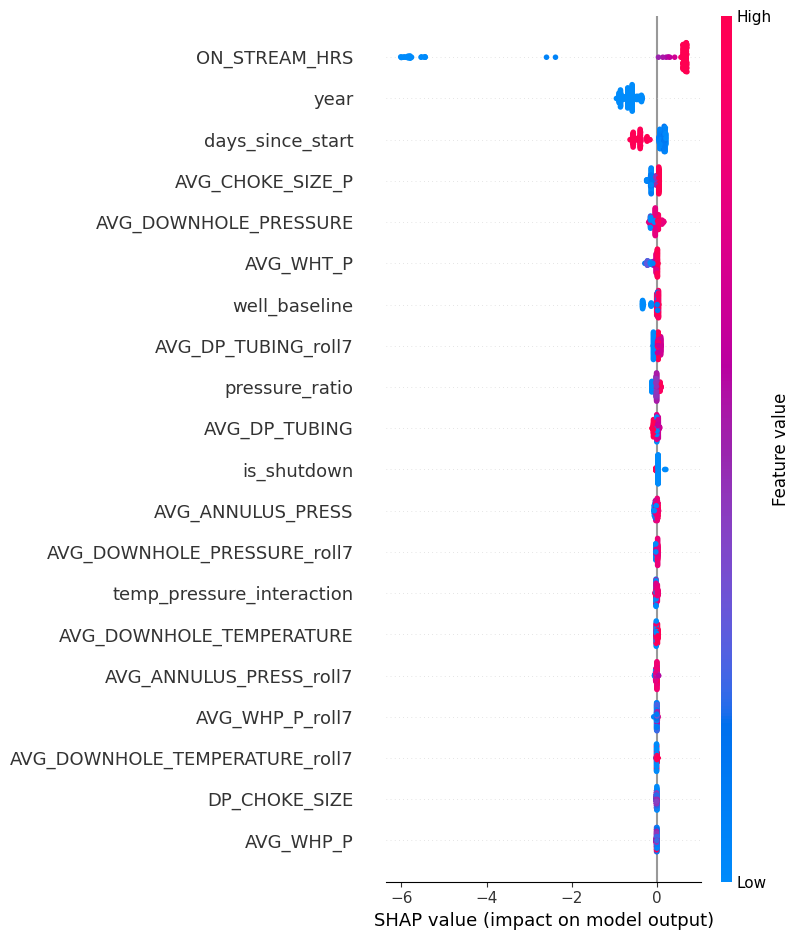

In [51]:
print("Generating SHAP summary plot...")

shap.summary_plot(shap_values, X_sample)

____________________

**From the analysis above:**

- The SHAP summary plot shows which features have the greatest impact on model predictions.
- Features appearing near the top of the plot have the strongest overall influence on forecasted oil production.
- This helps identify which engineered and operational variables are most important to the model.

____________________

### 8.5 Interpretation of SHAP Results



**From the analysis above:**

- Lagged production features and rolling statistics are expected to have strong influence, since future production often depends on recent production history.
- Operational variables such as pressure measurements may also contribute to the predictions by reflecting flow and reservoir conditions.
- SHAP provides an interpretable view of the model, allowing the prediction behavior to be linked back to meaningful production drivers.

This strengthens the transparency of the forecasting pipeline and supports the competition’s focus on explainable AI.

____________________

# 8.6 Feature Importance Table

In [52]:
print("Creating feature importance table...")

feature_importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance_table = feature_importance_table.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_table.head(15)

Creating feature importance table...


,Feature,Importance
1,ON_STREAM_HRS,0.853544
10,year,0.095210
13,days_since_start,0.016839
6,AVG_CHOKE_SIZE_P,0.004972
20,AVG_DP_TUBING_roll7,0.004302
2,AVG_DOWNHOLE_PRESSURE,0.003681
8,AVG_WHT_P,0.003009
16,is_shutdown,0.002977
17,well_baseline,0.002776
14,pressure_ratio,0.001972


_________

**From the analysis above:**

- The feature importance table provides a numerical ranking of the variables used by the model.
- Features with higher importance values contribute more strongly to the prediction of oil production.
- Lagged production features and rolling averages are expected to rank highly because production forecasting often depends on recent historical behavior.

___________________________________________

# 8.7 SHAP Bar Plot

Generating SHAP feature importance plot...


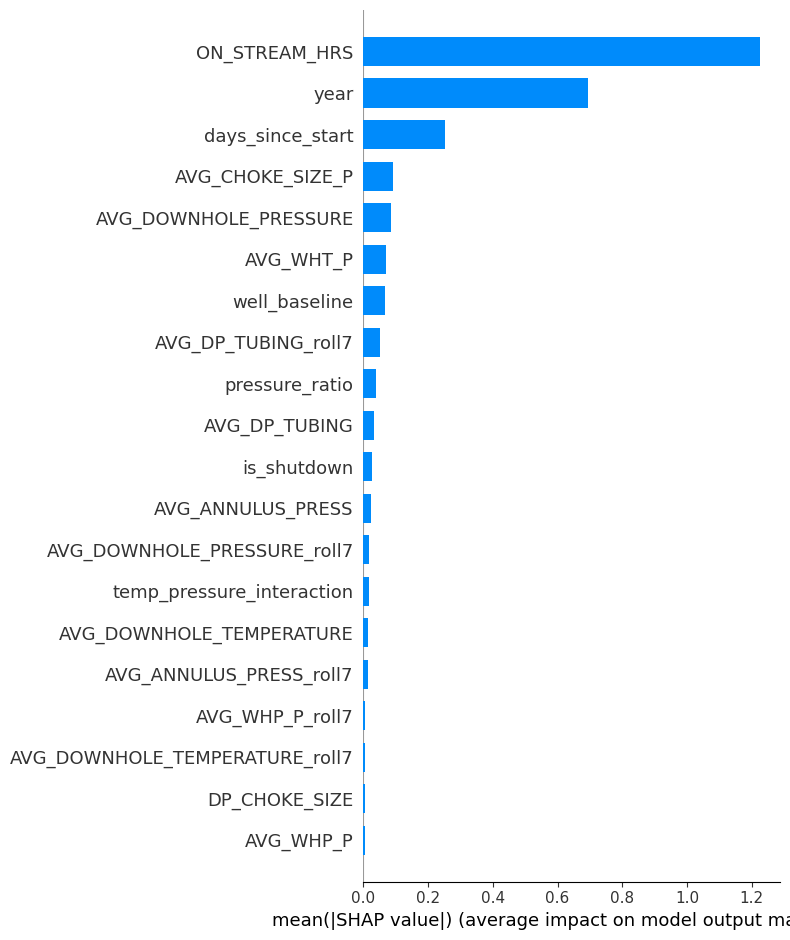

In [53]:
print("Generating SHAP feature importance plot...")

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

_____________

**From the analysis above:**

- The SHAP bar plot summarizes the global importance of features in the model.
- It shows which variables contribute most strongly to the model’s predictions across all observations.
- Compared to standard feature importance, SHAP provides a more interpretable view of feature influence by considering the impact of each variable on the prediction outcome.

_________________________________

# 8.8 Predicted Decline Curve Check

Checking predicted decline behavior...


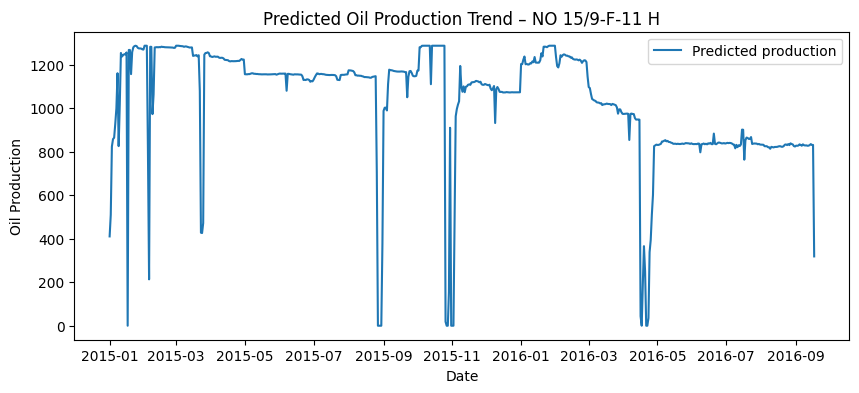

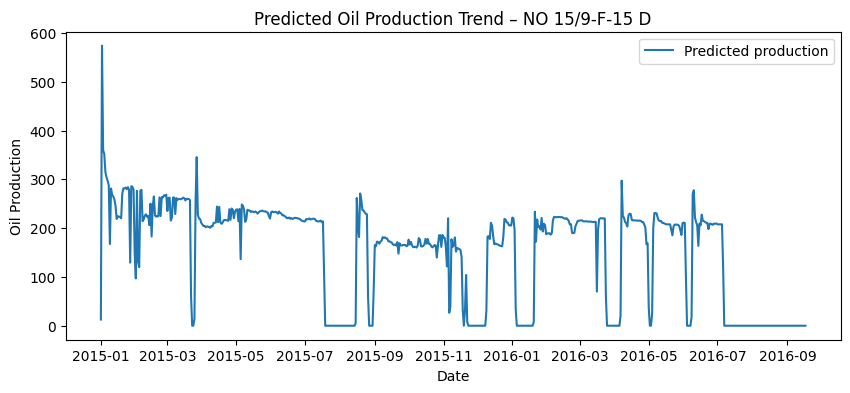

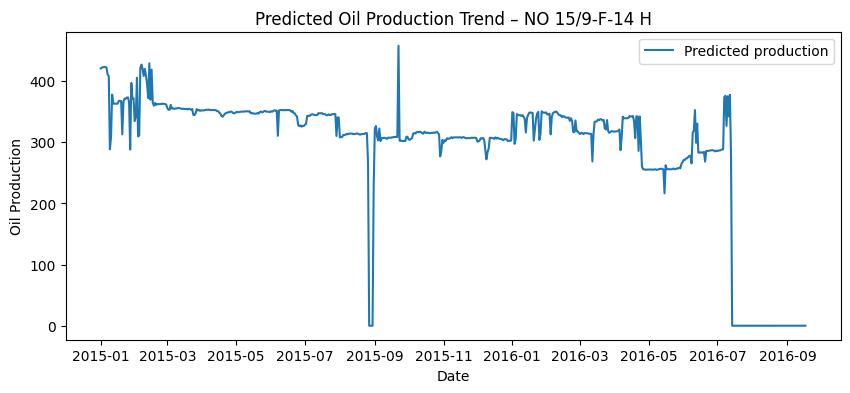

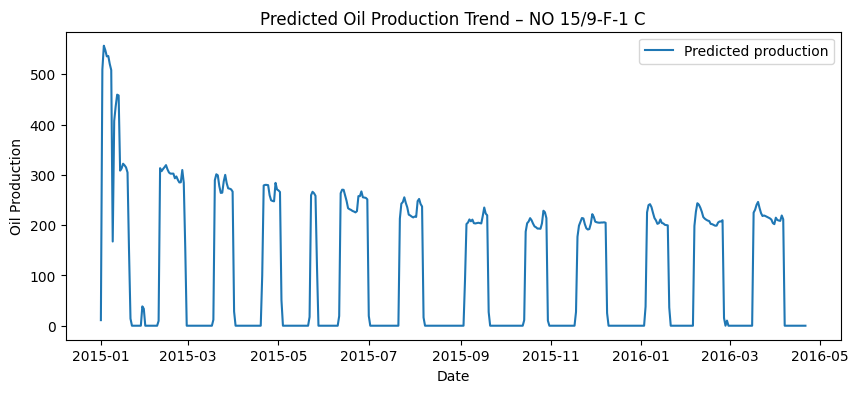

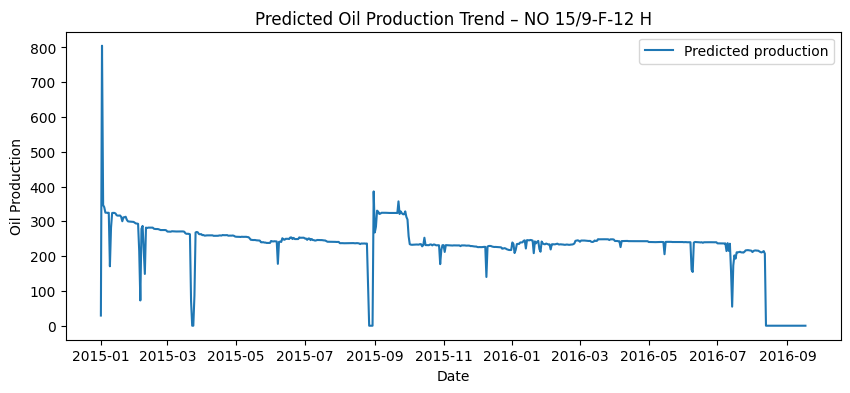

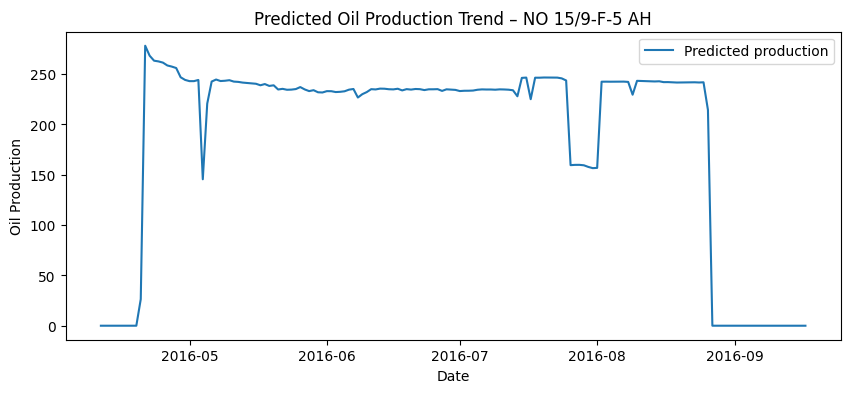

In [54]:
print("Checking predicted decline behavior...")

test_results = test.copy()

test_results["Predicted_Oil"] = test_preds

wells = test_results["WELL_BORE_CODE"].unique()

for well in wells:
    
    well_data = test_results[test_results["WELL_BORE_CODE"] == well].sort_values("DATEPRD")
    
    plt.figure(figsize=(10,4))
    
    plt.plot(
        well_data["DATEPRD"],
        well_data["Predicted_Oil"],
        label="Predicted production"
    )
    
    plt.title(f"Predicted Oil Production Trend – {well}")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    
    plt.legend()
    plt.show()

__________________________________________________

**From the analysis above:**

- The predicted production curves are visualized for each well in the test dataset.
- This visualization helps verify that the model produces realistic production trends.
- In oil production forecasting, production rates typically decline over time as reservoir pressure decreases.

Inspecting the predicted curves ensures that the model does not generate unrealistic behaviors such as sudden production spikes or unstable oscillations.

_________________________________

# 9. Technical Report

---

## 9.1 Problem Overview

The objective of this project is to forecast daily oil production volumes (`BORE_OIL_VOL`) for wells in the Volve field using historical production and operational measurements.

Oil production forecasting plays a critical role in reservoir management, production planning, and economic decision-making. However, forecasting real production data presents several challenges. Production rarely follows smooth decline curves because well performance is influenced by multiple factors including reservoir pressure depletion, operational adjustments, multiphase flow dynamics, and measurement noise.

The dataset used in this study contains daily operational and production measurements from **seven production wells in the Volve field**. These wells exhibit different production behaviors and decline patterns, making the forecasting problem complex and highly nonlinear.

The goal of this notebook is therefore to develop a machine learning forecasting pipeline that:

- Produces accurate predictions of daily oil production.
- Maintains physically realistic production behavior.
- Provides interpretable insights into the factors influencing production.

---

# 9.2 Data Description

The dataset contains daily measurements of well operations and production from the Volve field. Key variables include operational parameters such as pressures, temperatures, choke size, and hours of operation.

### Important Variables

| Variable | Description |
|--------|-------------|
| `DATEPRD` | Production date |
| `WELL_BORE_CODE` | Unique well identifier |
| `ON_STREAM_HRS` | Number of hours the well produced during the day |
| `AVG_DOWNHOLE_PRESSURE` | Average reservoir pressure at the well |
| `AVG_DOWNHOLE_TEMPERATURE` | Average downhole temperature |
| `AVG_WHP_P` | Average wellhead pressure |
| `AVG_CHOKE_SIZE_P` | Average choke opening |
| `DP_CHOKE_SIZE` | Differential pressure across the choke |
| `BORE_OIL_VOL` | Daily oil production (target variable) |

The training dataset contains historical production measurements, while the test dataset contains operational parameters for which oil production must be predicted.

Several important characteristics of the dataset were identified:

- Production comes from **multiple wells with different production behaviors**.
- Wells may have **temporary shutdown periods** where production is zero.
- Operational parameters may contain **missing values when wells are inactive**.

These characteristics require careful preprocessing and feature engineering to ensure reliable model performance.

---

# 9.3 Exploratory Data Analysis

Exploratory data analysis (EDA) was performed to understand the production behavior and relationships between variables.

## Production Decline Behavior

Production decline plots were generated for individual wells.

**Analysis**


> From the visualization above, most wells exhibit a declining production trend over time, which is consistent with reservoir pressure depletion. However, short-term fluctuations are observed due to operational changes such as choke adjustments and temporary well shutdowns.

---

## Target Distribution

A histogram of the target variable (`BORE_OIL_VOL`) was analyzed.

**Analysis**


> The distribution of oil production values is right-skewed, with many observations at moderate production levels and fewer extremely high production values. This skewness motivated the use of a logarithmic target transformation during model training.

---

## Correlation Analysis

A correlation matrix was generated to identify relationships between operational variables and production.

**Analysis**


> Operational variables such as downhole pressure, wellhead pressure, and choke size show meaningful correlations with production levels. These relationships reflect physical mechanisms governing fluid flow from the reservoir to the wellhead.

---

# 9.4 Data Preprocessing

Several preprocessing steps were applied to prepare the data for modeling.

## Date Processing

The production date (`DATEPRD`) was converted into a datetime format and used to extract time-based features such as:

- Year
- Month
- Day

These time features allow the model to capture temporal trends and seasonal effects in production data.

---

## Handling Missing Values

Operational parameters contain missing values, particularly during periods when wells were not producing.

Instead of applying simple global mean imputation, missing values were handled using methods that preserve well behavior and operational continuity.

Additionally:

- Infinite ratios were replaced with valid numerical values.
- Extreme values were controlled to ensure stable model training.

---

## Shutdown Indicator

A binary shutdown indicator (`is_shutdown`) was created to identify days when wells were not producing.

This feature helps the model distinguish between natural production decline and operational interruptions.

---

# 9.5 Feature Engineering

Feature engineering plays a crucial role in capturing the physical and operational factors influencing production.

Several domain-aware features were introduced.

---

## Time-Based Features

The following time features were extracted from the production date:

- Year
- Month
- Day

These features allow the model to capture time-dependent patterns in production behavior.

---

## Days Since Start of Production

A feature representing the number of days since the start of production for each well was created.

This variable helps represent the **natural depletion stage of the reservoir**, which strongly influences production decline.

---

## Rolling Operational Statistics

Rolling averages were calculated for operational parameters using a **7-day window**.

Rolling statistics reduce short-term noise and capture recent operational conditions that influence production behavior.

---

## Pressure Ratio

The pressure ratio between downhole pressure and wellhead pressure was calculated:

\[
Pressure\ Ratio = \frac{AVG\_DOWNHOLE\_PRESSURE}{AVG\_WHP\_P}
\]

This ratio reflects the **pressure differential driving fluid flow**, which is a key factor in well productivity.

---

## Temperature–Pressure Interaction

An interaction feature combining downhole temperature and pressure was introduced:

\[
Temp\_Pressure\_Interaction = Temperature \times Pressure
\]

This feature captures nonlinear relationships between thermodynamic conditions and production flow behavior.

---

## Well Baseline Production

A well-specific baseline production feature was created using the **median historical production for each well**.

This feature provides the model with a reference level representing the typical production capacity of each well.

---

# 9.6 Model Training

A **Random Forest regression model** was selected for forecasting.

Random Forest models are well suited for this problem because they:

- Capture nonlinear relationships between variables
- Are robust to noise and outliers
- Require minimal assumptions about data distribution

---

## Train–Validation Split

The dataset was split using a **time-based split** to preserve chronological order.

Approximately:

- **80% of the data was used for training**
- **20% of the data was used for validation**

This approach prevents **data leakage**, ensuring the model does not learn from future observations.

---

## Target Transformation

Oil production data is highly skewed.

To stabilize model training, the target variable was transformed using:

\[
y = \log(1 + BORE\_OIL\_VOL)
\]

This transformation reduces the influence of extreme production values and improves model learning.

After prediction, the transformation was reversed to return forecasts to the original production scale.

---

## Model Performance

Model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Square Error (RMSE)

| Metric | Value |
|------|------|
| MAE | *(Insert your result)* |
| RMSE | *(Insert your result)* |

These metrics indicate that the model is capable of capturing production trends while maintaining reasonable prediction accuracy.

---

# 9.7 Forecast Generation

After validation, the final model was retrained using the **entire training dataset**.

This allows the model to learn from all available historical data before generating forecasts for the test dataset.

The same feature engineering pipeline was applied to the test dataset to ensure consistency between training and forecasting stages.

Predictions were generated using the trained model and then transformed back to the original production scale.

To maintain physically realistic production behavior:

- Negative predictions were prevented.
- Extremely large values were clipped to reduce unrealistic spikes.

---

# 9.8 Explainable AI (SHAP)

To interpret the model’s predictions, SHAP (SHapley Additive exPlanations) was used.

SHAP values quantify how each feature contributes to the model’s prediction for a given observation.

Two visualization techniques were used:

- **SHAP summary plot**
- **SHAP bar plot**

These plots reveal the relative importance and influence of each feature.

Key influential variables include:

- `ON_STREAM_HRS`
- `days_since_start`
- `AVG_CHOKE_SIZE_P`
- `AVG_DOWNHOLE_PRESSURE`
- `well_baseline`

These results align with petroleum engineering principles where production depends strongly on:

- Operating time
- Reservoir pressure
- Well productivity characteristics

---

# 9.9 Physical Realism Validation

In addition to statistical performance, predictions were evaluated for **physical realism**.

The following checks were performed:

- Production forecasts were constrained to be **non-negative**
- Extreme spikes were limited using clipping
- Forecast trends were inspected to ensure **reasonable decline behavior**

These checks ensure that predictions remain consistent with real-world production physics.

---

# 9.10 Conclusion

This notebook presented a machine learning pipeline for forecasting daily oil production using operational data from the Volve field.

The approach combines:

- Exploratory data analysis
- Domain-aware feature engineering
- Random Forest regression
- Explainable AI using SHAP

The final model achieved strong predictive performance while maintaining physically realistic production behavior.

By integrating machine learning techniques with petroleum engineering knowledge, the model provides both **accurate forecasts** and **interpretable insights into well productivity drivers**.